In [118]:
# import librairies for data manipulation and numerical operations
import pandas as pd
import numpy as np

# import datasets from sklearn
from sklearn.datasets import load_iris 

# import preprocessing tools 
from sklearn.preprocessing import StandardScaler 

# Import clustering algo

from sklearn.cluster import KMeans, MeanShift, DBSCAN, AgglomerativeClustering

# import evaluaration metrics
from sklearn.metrics import silhouette_score, davies_bouldin_score,calinski_harabasz_score
from sklearn.metrics import silhouette_samples

# import vizualisation libraries
import matplotlib.pyplot as plt
from matplotlib import cm
import seaborn as sns

# improve dataset visualisation with pandas

pd.set_option('display.width', None)       # Automatically detect the terminal/notebook width and display with no limit
pd.set_option('display.max_columns', None)  # Display all columns with no limit


# Set random seed for reproductivity
np.random.seed(42)

# verification that all has beeing imported
print("✅ All libraries importted successfully ! ")


✅ All libraries importted successfully ! 


In [119]:
# Load dataset and displays iris keys
iris = load_iris()
print(iris.keys()) 

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [120]:
# extract features from iris dataset
X = iris.data

In [121]:
# extract Target from iris dataset  (Use only for visualization)
target = iris.target

In [122]:
# create a DataFrame of features for better visualizations
df = pd.DataFrame(X, columns = feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [123]:
df['Species'] = target

In [124]:
# display basics informnation about dataset 

print(f"Dataset shape:  {df.shape}")
# the shape is (150, 5) means (150 lignes et 5 colonnes[with 4 variables inde and 1 variable depe which is the Target])

Dataset shape:  (150, 5)


In [125]:
print(f"Features Names: {iris.feature_names}")

Features Names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [126]:
print(f"Targets Nmaes : {iris.target_names}")

Targets Nmaes : ['setosa' 'versicolor' 'virginica']


In [127]:
print(f"First 5 rows of the dataset:\n{df.head()}")

First 5 rows of the dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:
# create a standart scaler object 

In [128]:
scaled = StandardScaler()
# StandardScaler Fit the scale to the data and transform it 
# fit () calculates the means and the standart deviation
# transform() applies standartization to the data in order to have mean 0 and std 1

In [129]:
X_scaled = scaled.fit_transform(X)



In [ ]:
# verified that the data has been weel standatized

In [139]:
# before StandardScaler : Original data
print(f"Original mean:  {X.mean(axis=0)}")
print(f"Original std:  {X.std(axis=0)}")
print("=" * 35)
# after StandardScaler: scaled data
print(f"Original mean:  {X_scaled.mean(axis=0)}")
print(f"Original std:  {X_scaled.std(axis=0)}")


Original mean:  [5.84333333 3.05733333 3.758      1.19933333]
Original std:  [0.82530129 0.43441097 1.75940407 0.75969263]
Original mean:  [-1.69031455e-15 -1.84297022e-15 -1.69864123e-15 -1.40924309e-15]
Original std:  [1. 1. 1. 1.]


In [136]:
# create dataFrame with scaled data for reference

df_scaled = pd.DataFrame(X_scaled, columns = iris.feature_names) 
df_scaled

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


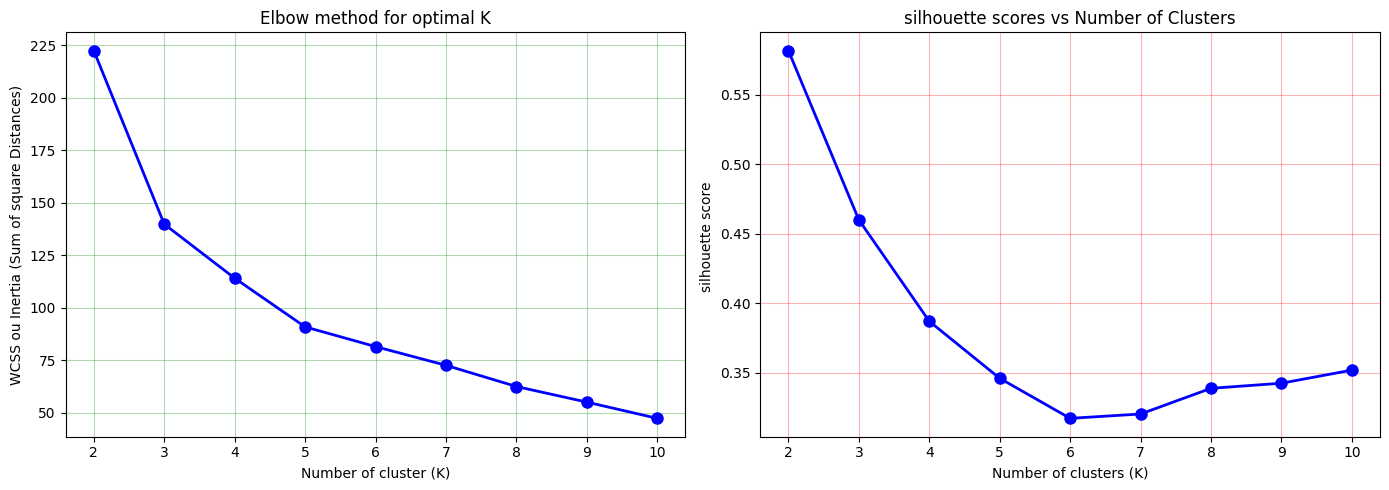

Silhouette scrore for different k values
K= 2 : Silhouette score = 0.5818
K= 3 : Silhouette score = 0.4599
K= 4 : Silhouette score = 0.3869
K= 5 : Silhouette score = 0.3459
K= 6 : Silhouette score = 0.3171
K= 7 : Silhouette score = 0.3202
K= 8 : Silhouette score = 0.3387
K= 9 : Silhouette score = 0.3424
K= 10 : Silhouette score = 0.3518
Inertias for different k values
K= 2 : inertias = 222.3617
K= 3 : inertias = 139.8205
K= 4 : inertias = 114.0925
K= 5 : inertias = 90.9275
K= 6 : inertias = 81.5444
K= 7 : inertias = 72.6311
K= 8 : inertias = 62.5406
K= 9 : inertias = 55.1195
K= 10 : inertias = 47.3910


In [169]:
# find the numbers of cluster using Elbow method
inertias = []
silhouette_scores = []
K_values = range(2,11)

for k in K_values:
    kmeans = KMeans(n_clusters =k, init = 'k-means++', n_init = 10, random_state = 42)

    kmeans.fit(X_scaled)

    inertias.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, kmeans.labels_)

    silhouette_scores.append(score)

fig, axes = plt.subplots(1,2,figsize=(14,5))

# plot 1 : Elbow Curve
axes[0].plot(K_values,inertias, 'bo-', linewidth = 2,markersize = 8)
axes[0].set_xlabel('Number of cluster (K)')
axes[0].set_ylabel('WCSS ou Inertia (Sum of square Distances)')
axes[0].set_title("Elbow method for optimal K")
axes[0].grid(True, alpha = 0.3, color ='g'  )


# plot 2 : Silhouette Curve
axes[1].plot(K_values,silhouette_scores, 'bo-', linewidth = 2,markersize = 8)
axes[1].set_xlabel("Number of clusters (K)")
axes[1].set_ylabel("silhouette score ")
axes[1].set_title('silhouette scores vs Number of Clusters')
axes[1].grid(True, alpha = 0.3,color ='r' )


plt.tight_layout()
plt.show()

print(f'Silhouette scrore for different k values')
for k, score in zip(K_values,silhouette_scores):
    print (f"K= {k} : Silhouette score = {score:.4f}")


print(f'Inertias for different k values')
for k, score in zip(K_values,inertias):
    print (f"K= {k} : inertias = {score:.4f}")